In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Color palette
BLUE  = '#3266ad'
TEAL  = '#1D9E75'
CORAL = '#D85A30'
AMBER = '#BA7517'
GRAY  = '#888780'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 130,
})

DATA_DIR = os.getcwd()  # expects CSVs in the same folder as this notebook
print("Data directory:", DATA_DIR)
print("CSV files found:", [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])

Data directory: C:\Users\ShepSharesUser1\Desktop\NewForce\capstone\EPTA
CSV files found: ['01_annual_ridership_enrollment.csv', '02_monthly_ridership_fy2425.csv', '03_monthly_ridership_fy2526.csv', '04_survey_frequency_results.csv', '05_survey_likert_results.csv', '06_hourly_ridership_fy2425.csv']


---
## 1. Annual Ridership History (FY11-12 – FY25-26)

In [2]:
annual = pd.read_csv(os.path.join(DATA_DIR, '01_annual_ridership_enrollment.csv'))
annual.head()

,fiscal_year,annual_riders,fall_enrollment,anomaly_flag,partial_year,riders_per_100_students
0,FY11-12,20071,4393,0,0,456.9
1,FY12-13,82006,4326,1,0,1895.7
2,FY13-14,17302,4221,0,0,409.9
3,FY14-15,17992,4041,0,0,445.2
4,FY15-16,18710,3861,0,0,484.6


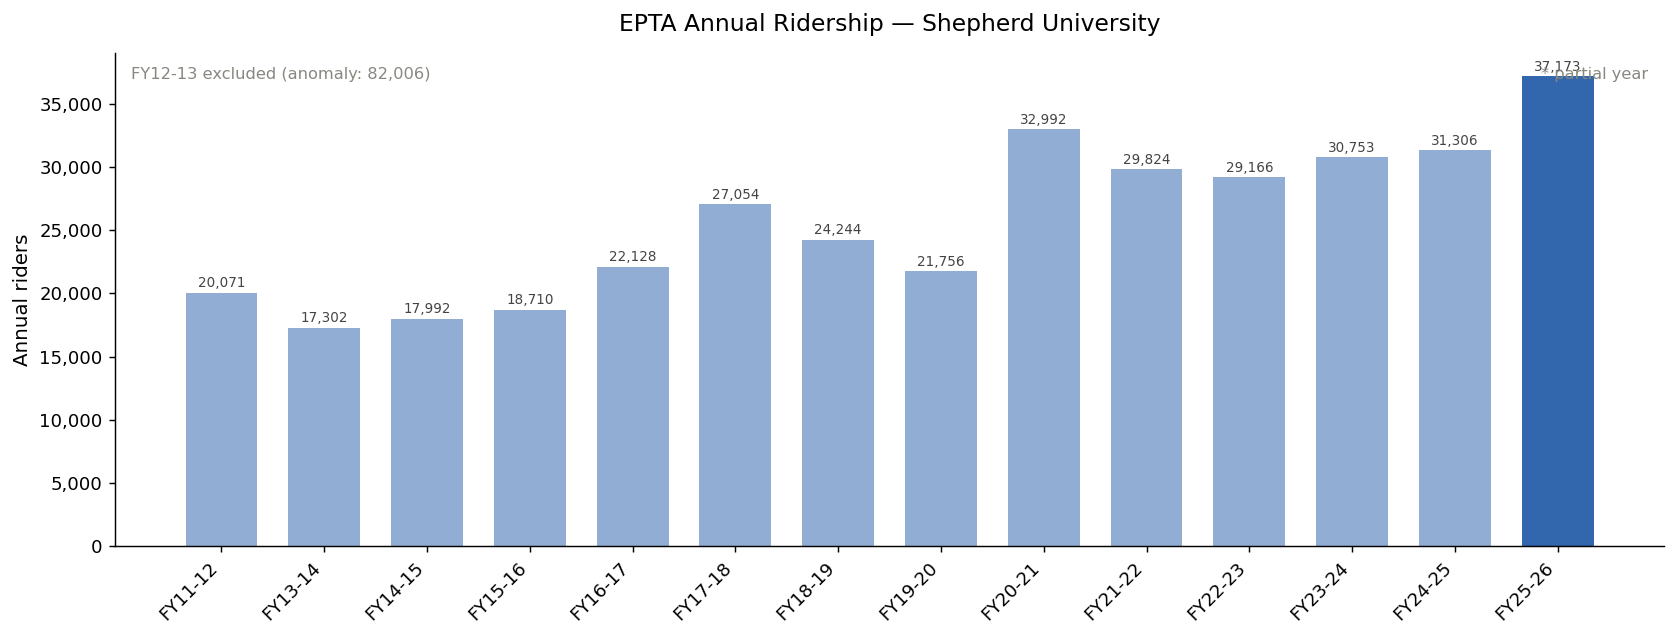

In [3]:
df_plot = annual[annual['anomaly_flag'] == 0].copy()

fig, ax = plt.subplots(figsize=(13, 5))
colors = [BLUE if fy == 'FY25-26' else BLUE + '88' for fy in df_plot['fiscal_year']]
ax.bar(df_plot['fiscal_year'], df_plot['annual_riders'], color=colors, width=0.7)

ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['fiscal_year'], rotation=45, ha='right')
ax.set_title('EPTA Annual Ridership — Shepherd University', pad=12)
ax.set_ylabel('Annual riders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for i, (fy, v) in enumerate(zip(df_plot['fiscal_year'], df_plot['annual_riders'])):
    ax.text(i, v + 200, f'{int(v):,}', ha='center', va='bottom', fontsize=7.5, color='#444')

ax.annotate('FY12-13 excluded (anomaly: 82,006)', xy=(0.01, 0.97),
            xycoords='axes fraction', fontsize=9, color=GRAY, va='top')
ax.annotate('* partial year', xy=(0.99, 0.97),
            xycoords='axes fraction', fontsize=9, color=GRAY, va='top', ha='right')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_01_annual_ridership.png'), bbox_inches='tight')
plt.show()

---
## 2. Enrollment vs. Ridership (Dual Axis)

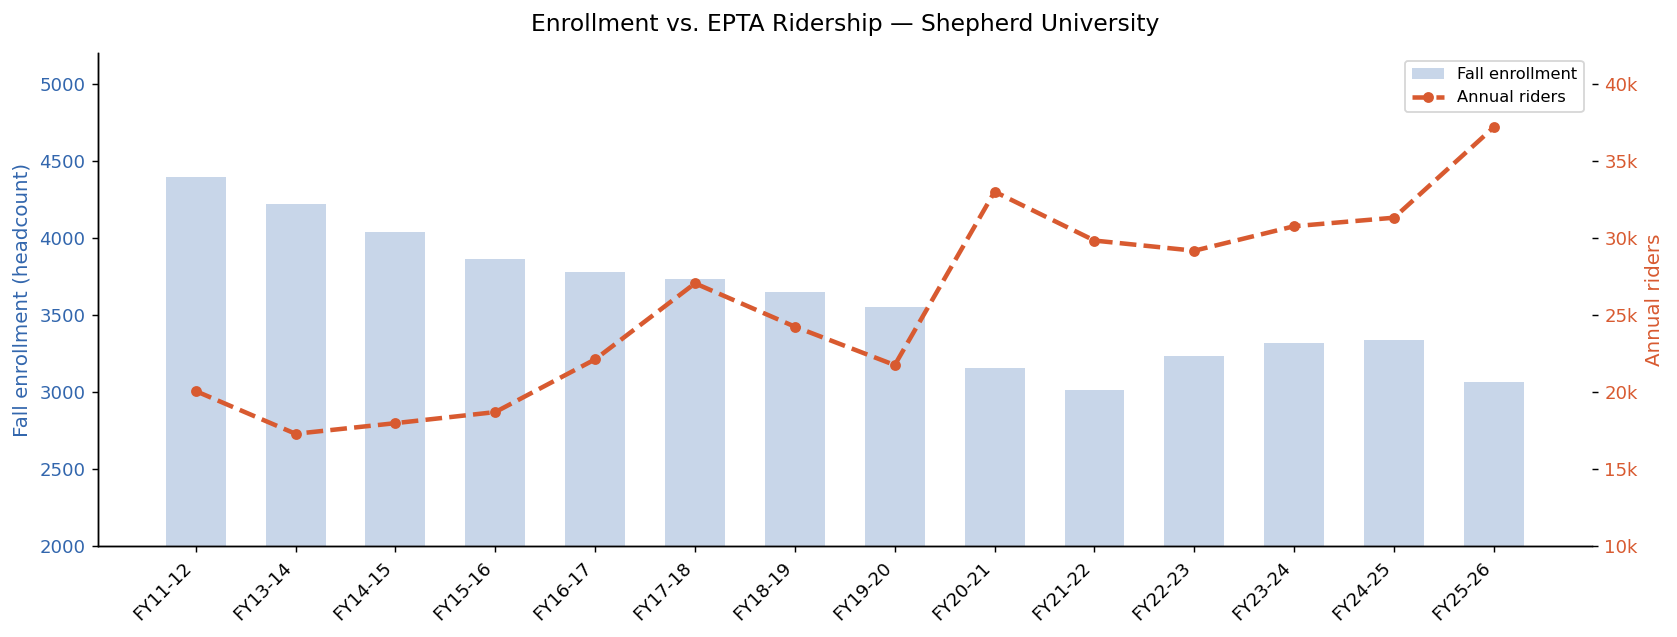

In [4]:
df = annual[annual['anomaly_flag'] == 0].copy()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

x = np.arange(len(df))
ax1.bar(x, df['fall_enrollment'], color=BLUE + '44', width=0.6, label='Fall enrollment')
ax1.set_ylabel('Fall enrollment (headcount)', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax1.set_ylim(2000, 5200)

ax2.plot(x, df['annual_riders'], color=CORAL, linewidth=2.5,
         marker='o', markersize=5, label='Annual riders', linestyle='--')
ax2.set_ylabel('Annual riders', color=CORAL)
ax2.tick_params(axis='y', labelcolor=CORAL)
ax2.set_ylim(10000, 42000)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v/1000)}k'))

ax1.set_xticks(x)
ax1.set_xticklabels(df['fiscal_year'], rotation=45, ha='right')
ax1.set_title('Enrollment vs. EPTA Ridership — Shepherd University', pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_02_enrollment_vs_ridership.png'), bbox_inches='tight')
plt.show()

---
## 3. Riders per 100 Enrolled Students

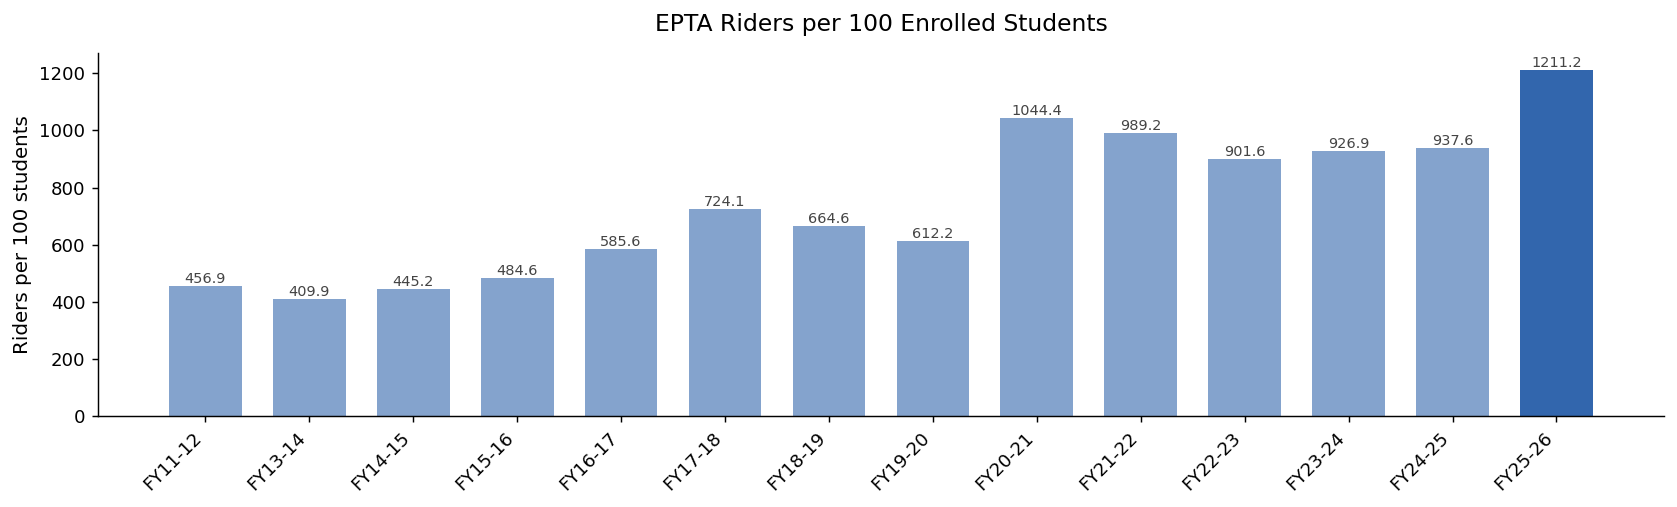

In [5]:
df = annual[annual['anomaly_flag'] == 0].copy()

fig, ax = plt.subplots(figsize=(13, 4))
colors = [BLUE if fy == 'FY25-26' else BLUE + '99' for fy in df['fiscal_year']]
ax.bar(df['fiscal_year'], df['riders_per_100_students'], color=colors, width=0.7)

ax.set_xticks(range(len(df)))
ax.set_xticklabels(df['fiscal_year'], rotation=45, ha='right')
ax.set_title('EPTA Riders per 100 Enrolled Students', pad=12)
ax.set_ylabel('Riders per 100 students')

for i, v in enumerate(df['riders_per_100_students']):
    ax.text(i, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=8, color='#444')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_03_riders_per_100.png'), bbox_inches='tight')
plt.show()

---
## 4. Monthly Ridership by Route — FY2024-25

In [6]:
m2425 = pd.read_csv(os.path.join(DATA_DIR, '02_monthly_ridership_fy2425.csv'))
m2425

,month,rf1_am,express,rf1_pm,service_days_rf1,service_days_express,total
0,Aug-24,678,376,178,5,5,1232
1,Sep-24,2495,1254,728,20,20,4477
2,Oct-24,2627,1259,793,21,21,4679
3,Nov-24,2207,875,633,16,16,3715
4,Dec-24,1320,411,545,10,10,2276
5,Jan-25,2360,959,910,14,14,4229
6,Feb-25,3302,1121,1036,19,19,5459


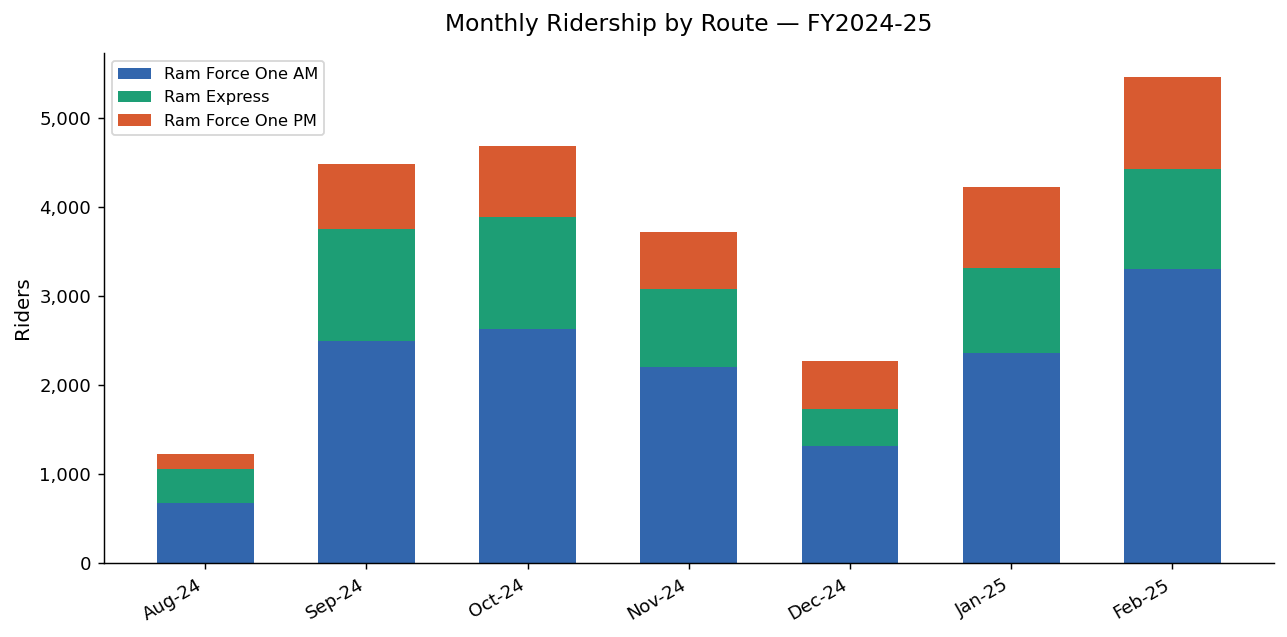

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(m2425))
w = 0.6

ax.bar(x, m2425['rf1_am'],  width=w, label='Ram Force One AM', color=BLUE)
ax.bar(x, m2425['express'], width=w, bottom=m2425['rf1_am'], label='Ram Express', color=TEAL)
ax.bar(x, m2425['rf1_pm'],  width=w, bottom=m2425['rf1_am'] + m2425['express'],
       label='Ram Force One PM', color=CORAL)

ax.set_xticks(x)
ax.set_xticklabels(m2425['month'], rotation=30, ha='right')
ax.set_title('Monthly Ridership by Route — FY2024-25', pad=12)
ax.set_ylabel('Riders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_04_monthly_fy2425.png'), bbox_inches='tight')
plt.show()

---
## 5. Monthly Ridership — FY25-26 vs. FY24-25

In [8]:
m2526 = pd.read_csv(os.path.join(DATA_DIR, '03_monthly_ridership_fy2526.csv'))
m2526

,month,rf1_am,express,rf1_pm,total,prior_year_total,yoy_pct_change
0,Aug-25,588,230,158,976,1067,-8.5
1,Sep-25,3409,989,798,5196,4663,11.4
2,Oct-25,3479,956,777,5212,4586,13.7
3,Nov-25,2651,639,711,4001,3579,11.8
4,Dec-25,1201,263,410,1874,2186,-14.3
5,Jan-26,2365,615,618,3598,2974,21.0
6,Feb-26,4271,1053,1177,6501,3997,62.6
7,Mar-26,3125,803,947,4875,3372,44.6
8,Apr-26,3174,788,922,4884,4534,7.7
9,May-26,51,5,0,56,348,-83.9


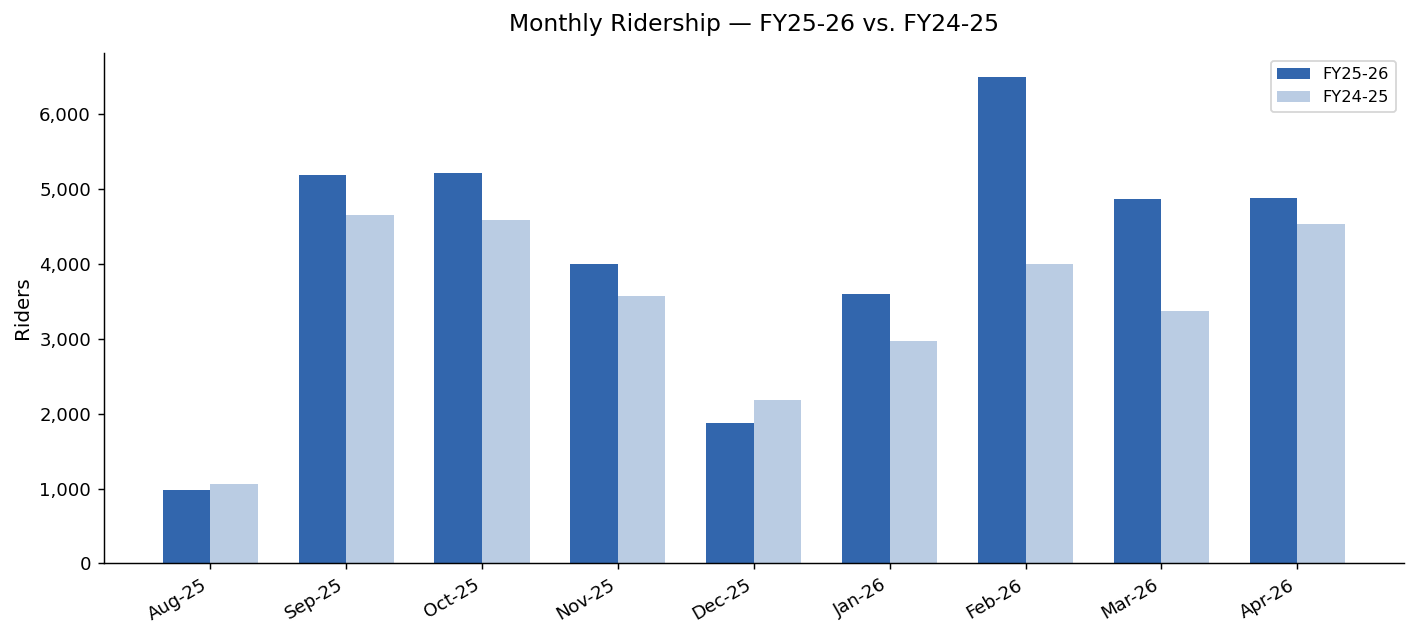

In [9]:
df = m2526[m2526['month'] != 'May-26'].copy()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df))
w = 0.35

ax.bar(x - w/2, df['total'], width=w, label='FY25-26', color=BLUE)
ax.bar(x + w/2, df['prior_year_total'], width=w, label='FY24-25', color=BLUE + '55')

ax.set_xticks(x)
ax.set_xticklabels(df['month'], rotation=30, ha='right')
ax.set_title('Monthly Ridership — FY25-26 vs. FY24-25', pad=12)
ax.set_ylabel('Riders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_05_monthly_fy2526_comparison.png'), bbox_inches='tight')
plt.show()

---
## 6. Year-over-Year % Change — FY25-26 vs. FY24-25

C:\Users\ShepSharesUser1\AppData\Local\Temp\ipykernel_20184\2056433411.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['month'], rotation=30, ha='right')


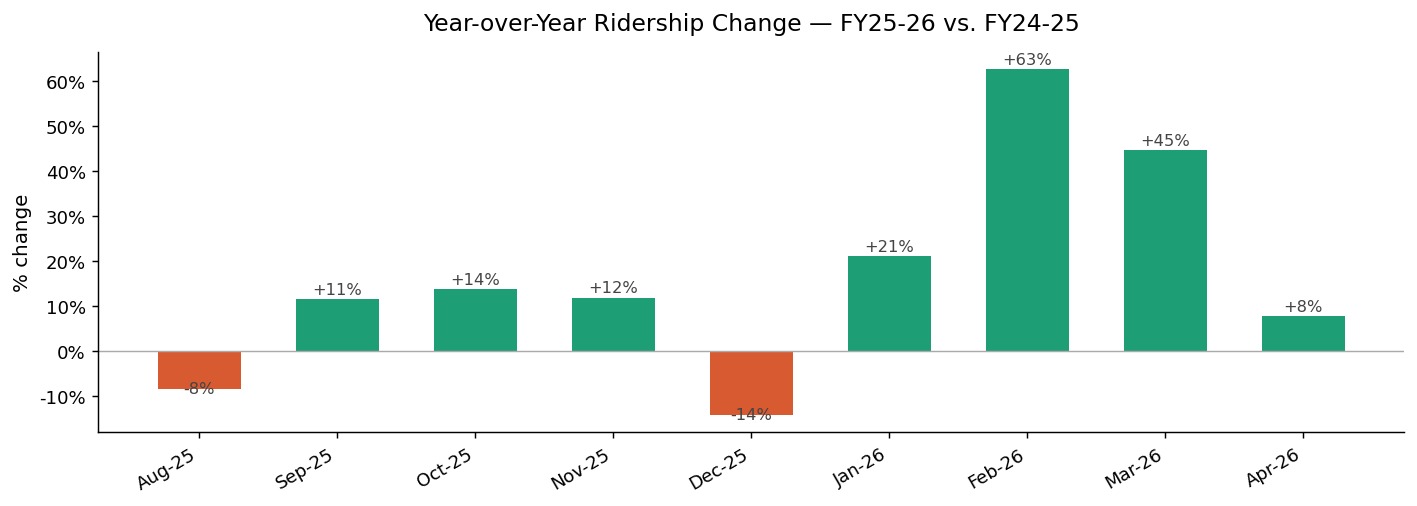

In [10]:
df = m2526[m2526['month'] != 'May-26'].copy()

fig, ax = plt.subplots(figsize=(11, 4))
colors = [TEAL if v >= 0 else CORAL for v in df['yoy_pct_change']]
ax.bar(df['month'], df['yoy_pct_change'], color=colors, width=0.6)
ax.axhline(0, color='#aaa', linewidth=0.8)

ax.set_title('Year-over-Year Ridership Change — FY25-26 vs. FY24-25', pad=12)
ax.set_ylabel('% change')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_xticklabels(df['month'], rotation=30, ha='right')

for i, v in enumerate(df['yoy_pct_change']):
    label = f'+{v:.0f}%' if v >= 0 else f'{v:.0f}%'
    ax.text(i, v + 0.5 if v >= 0 else v - 1.5, label,
            ha='center', va='bottom', fontsize=9, color='#444')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_06_yoy_change.png'), bbox_inches='tight')
plt.show()

---
## 7. Survey — Ride Frequency (Q2)

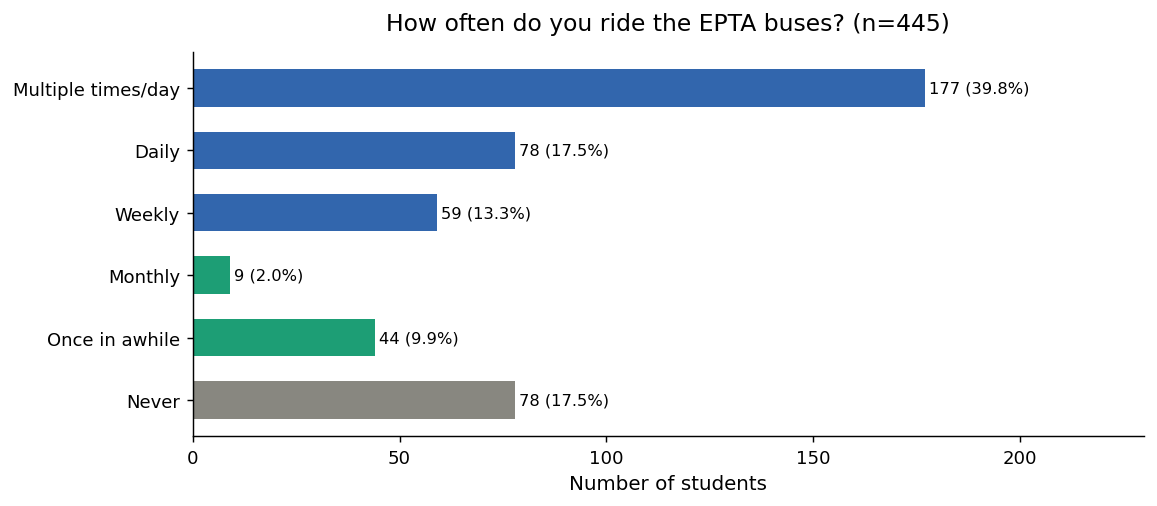

In [11]:
survey = pd.read_csv(os.path.join(DATA_DIR, '04_survey_frequency_results.csv'))
q2 = survey[survey['question'] == 'Q2 Ride frequency'].copy()

fig, ax = plt.subplots(figsize=(9, 4))
colors = [BLUE, BLUE, BLUE, TEAL, TEAL, GRAY]
ax.barh(q2['response'][::-1], q2['count'][::-1], color=colors[::-1], height=0.6)
ax.set_title('How often do you ride the EPTA buses? (n=445)', pad=12)
ax.set_xlabel('Number of students')

for i, (v, p) in enumerate(zip(q2['count'][::-1], q2['pct'][::-1])):
    ax.text(v + 1, i, f'{v} ({p:.1f}%)', va='center', fontsize=9)

ax.set_xlim(0, 230)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_07_survey_frequency.png'), bbox_inches='tight')
plt.show()

---
## 8. Survey — Reasons for Riding (Q3)

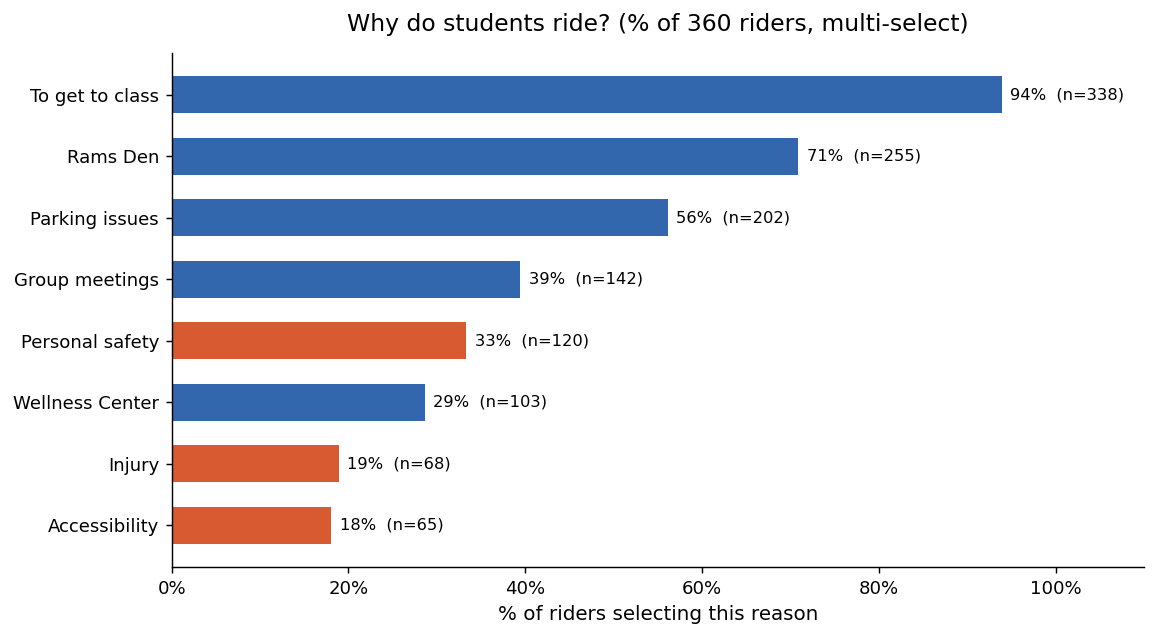

In [12]:
q3 = survey[survey['question'] == 'Q3 Reasons for riding'].sort_values('count').copy()

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [CORAL if r in ['Injury', 'Accessibility', 'Personal safety'] else BLUE
              for r in q3['response']]
ax.barh(q3['response'], q3['respondent_pct'], color=bar_colors, height=0.6)
ax.set_title('Why do students ride? (% of 360 riders, multi-select)', pad=12)
ax.set_xlabel('% of riders selecting this reason')
ax.set_xlim(0, 110)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))

for i, (v, c) in enumerate(zip(q3['respondent_pct'], q3['count'])):
    ax.text(v + 1, i, f'{v:.0f}%  (n={c})', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_08_survey_reasons.png'), bbox_inches='tight')
plt.show()

---
## 9. Survey — Importance & Critical Time Slots (Q6, Q7)

C:\Users\ShepSharesUser1\AppData\Local\Temp\ipykernel_20184\3898571225.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(q7['response'], rotation=20, ha='right')


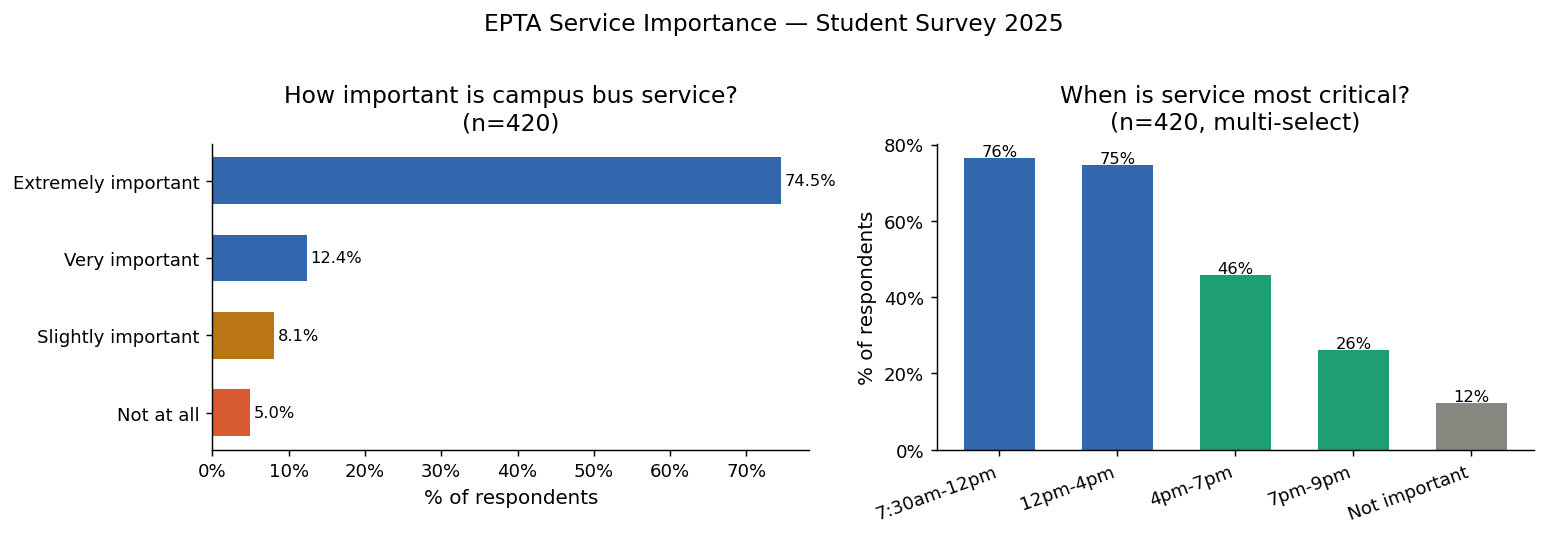

In [13]:
q6 = survey[survey['question'] == 'Q6 Importance'].copy()
q7 = survey[survey['question'] == 'Q7 Critical time slots'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Q6
colors6 = [BLUE, BLUE, AMBER, CORAL]
axes[0].barh(q6['response'][::-1], q6['pct'][::-1], color=colors6[::-1], height=0.6)
axes[0].set_title('How important is campus bus service?\n(n=420)', pad=8)
axes[0].set_xlabel('% of respondents')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
for i, (v, p) in enumerate(zip(q6['count'][::-1], q6['pct'][::-1])):
    axes[0].text(p + 0.5, i, f'{p:.1f}%', va='center', fontsize=9)

# Q7
colors7 = [BLUE, BLUE, TEAL, TEAL, GRAY]
axes[1].bar(q7['response'], q7['respondent_pct'], color=colors7, width=0.6)
axes[1].set_title('When is service most critical?\n(n=420, multi-select)', pad=8)
axes[1].set_ylabel('% of respondents')
axes[1].set_xticklabels(q7['response'], rotation=20, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
for i, v in enumerate(q7['respondent_pct']):
    axes[1].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9)

plt.suptitle('EPTA Service Importance — Student Survey 2025', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_09_survey_importance.png'), bbox_inches='tight')
plt.show()

---
## 10. Survey — Agreement Statements (Q9–Q12)

In [14]:
likert = pd.read_csv(os.path.join(DATA_DIR, '05_survey_likert_results.csv'))
likert

,question,strongly_agree_pct,agree_pct,disagree_pct,strongly_disagree_pct,n,agree_total_pct
0,Q9 Sufficient stops,61.35,32.61,3.62,2.42,414,93.96
1,Q10 Parking alleviated,62.71,26.63,6.05,4.60,413,89.34
2,Q11 Knows schedule,67.63,20.77,7.49,4.11,414,88.40
3,Q12 Satisfaction,59.81,33.66,3.63,2.91,413,93.47


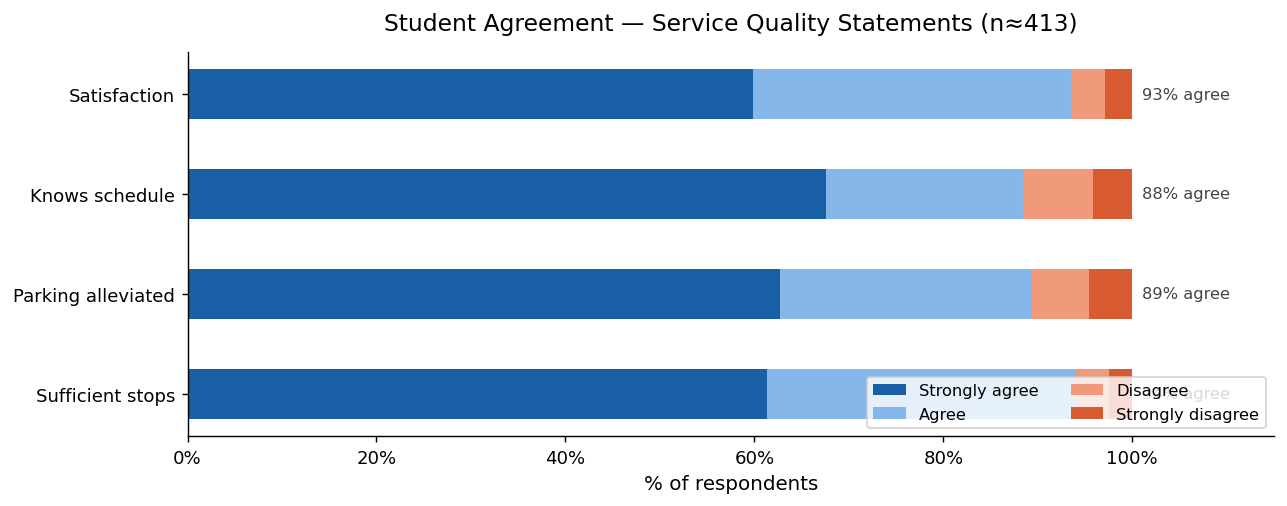

In [15]:
labels = [q.split(' ', 1)[1] for q in likert['question']]
sa = likert['strongly_agree_pct'].values
a  = likert['agree_pct'].values
d  = likert['disagree_pct'].values
sd = likert['strongly_disagree_pct'].values

fig, ax = plt.subplots(figsize=(10, 4))
y = np.arange(len(likert))
ax.barh(y, sa,       height=0.5, color='#185FA5', label='Strongly agree')
ax.barh(y, a,        height=0.5, left=sa,         color='#85B7EB', label='Agree')
ax.barh(y, d,        height=0.5, left=sa+a,       color='#F0997B', label='Disagree')
ax.barh(y, sd,       height=0.5, left=sa+a+d,     color=CORAL,     label='Strongly disagree')

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('% of respondents')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title('Student Agreement — Service Quality Statements (n≈413)', pad=12)
ax.legend(loc='lower right', fontsize=9, ncol=2)

for i, row in likert.iterrows():
    total = row['strongly_agree_pct'] + row['agree_pct']
    ax.text(101, i, f'{total:.0f}% agree', va='center', fontsize=9, color='#444')

ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_10_survey_likert.png'), bbox_inches='tight')
plt.show()

---
## 11. Hourly Ridership by Route — FY2024-25

In [16]:
hourly = pd.read_csv(os.path.join(DATA_DIR, '06_hourly_ridership_fy2425.csv'))
hourly

,route,hour_slot,total_riders
0,RF1_AM,7-8,933
1,RF1_AM,8-9,1494
2,RF1_AM,9-10,1911
3,RF1_AM,10-11,763
4,RF1_AM,11-12,2027
5,RF1_AM,12-1,2929
6,RF1_AM,1-2,2413
7,RF1_AM,2-3,1768
8,RF1_AM,3-4,1490
9,Express,7-8,33


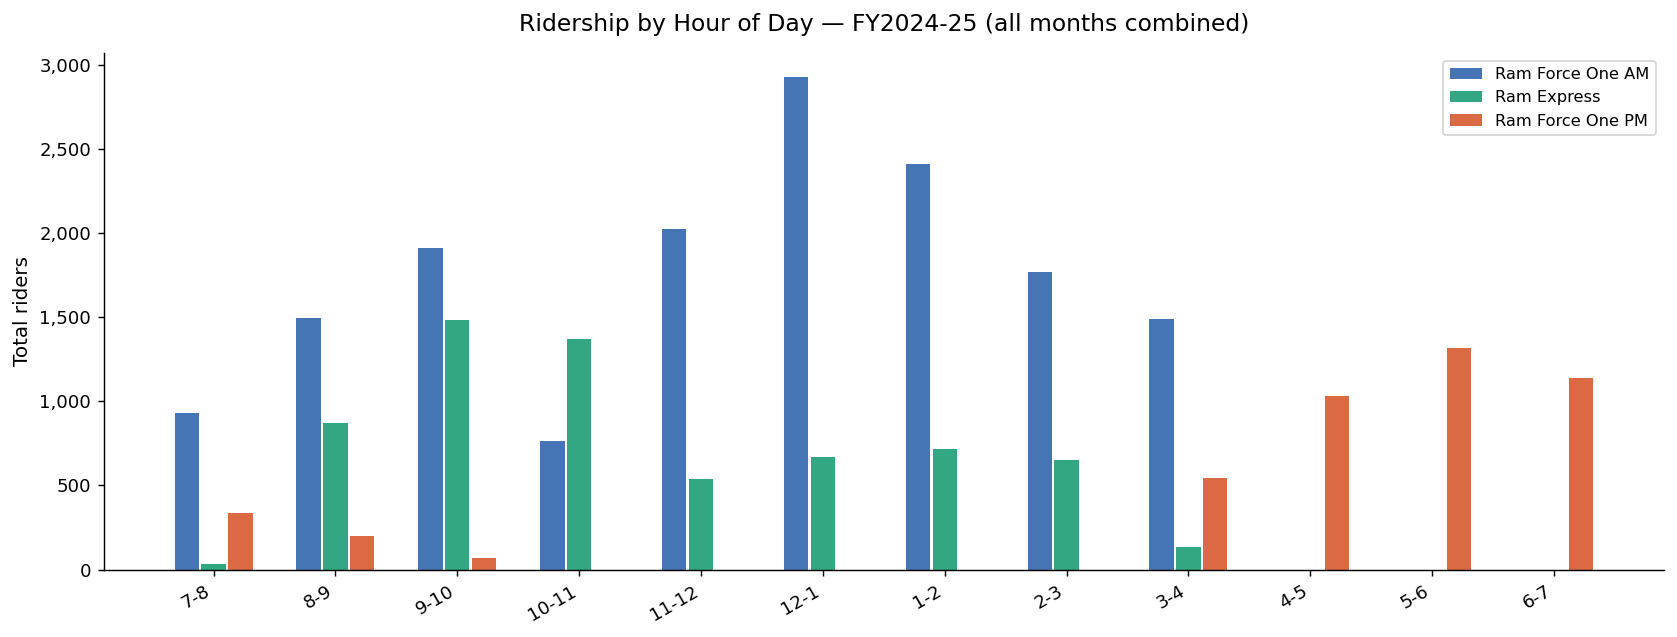

In [17]:
hour_order = ['7-8','8-9','9-10','10-11','11-12','12-1','1-2','2-3',
              '3-4','4-5','5-6','6-7']
route_colors = {'RF1_AM': BLUE, 'Express': TEAL, 'RF1_PM': CORAL}
route_labels  = {'RF1_AM': 'Ram Force One AM', 'Express': 'Ram Express', 'RF1_PM': 'Ram Force One PM'}
offsets = {'RF1_AM': -0.22, 'Express': 0, 'RF1_PM': 0.22}
w = 0.2

all_hours = [h for h in hour_order if h in hourly['hour_slot'].values]
x_map = {h: i for i, h in enumerate(all_hours)}

fig, ax = plt.subplots(figsize=(13, 5))
for route in ['RF1_AM', 'Express', 'RF1_PM']:
    sub = hourly[hourly['route'] == route]
    xs = [x_map[h] + offsets[route] for h in sub['hour_slot'] if h in x_map]
    ys = [sub[sub['hour_slot'] == h]['total_riders'].values[0]
          for h in sub['hour_slot'] if h in x_map]
    ax.bar(xs, ys, width=w, color=route_colors[route],
           label=route_labels[route], alpha=0.9)

ax.set_xticks(range(len(all_hours)))
ax.set_xticklabels(all_hours, rotation=30, ha='right')
ax.set_title('Ridership by Hour of Day — FY2024-25 (all months combined)', pad=12)
ax.set_ylabel('Total riders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_11_hourly_ridership.png'), bbox_inches='tight')
plt.show()

---
## 12. Survey — Student Type & Fee Support

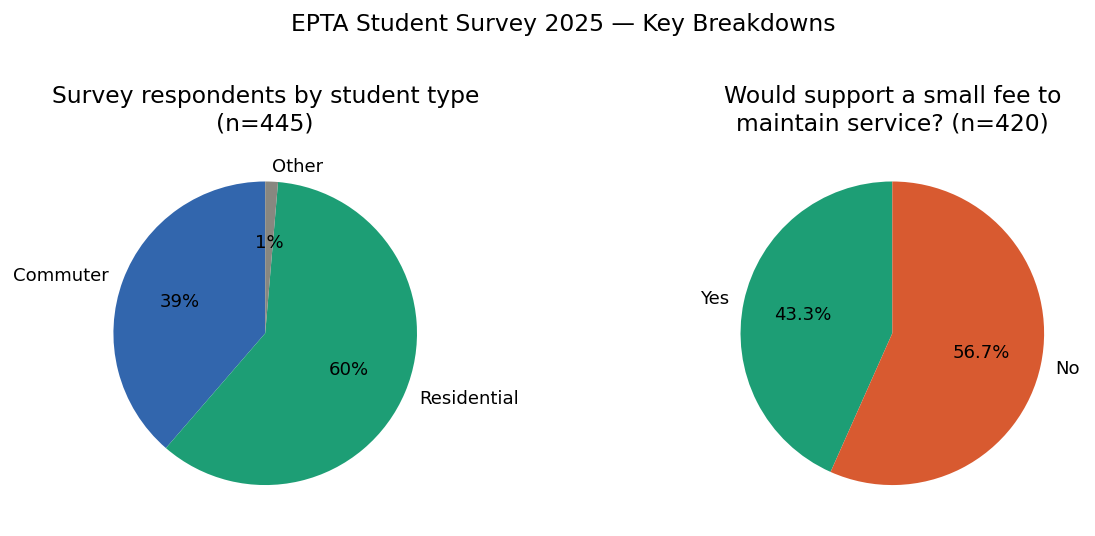

In [18]:
q1 = survey[survey['question'] == 'Q1 Student type']
q8 = survey[survey['question'] == 'Q8 Fee support']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].pie(q1['count'], labels=q1['response'],
            colors=[BLUE, TEAL, GRAY],
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 10})
axes[0].set_title('Survey respondents by student type\n(n=445)', pad=8)

axes[1].pie(q8['count'], labels=q8['response'],
            colors=[TEAL, CORAL],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Would support a small fee to\nmaintain service? (n=420)', pad=8)

plt.suptitle('EPTA Student Survey 2025 — Key Breakdowns', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'chart_12_survey_summary.png'), bbox_inches='tight')
plt.show()

---
## Summary — Key Numbers for Funding Case

| Metric | Value |
|--------|-------|
| FY25-26 riders (to date) | 37,173 |
| YoY growth vs. FY24-25 | +19% |
| Riders per 100 students (FY25-26) | 12.1+ |
| Survey respondents | 445 |
| Ride daily or multiple times/day | 57% |
| Rate service "extremely important" | 75% |
| Satisfied or strongly satisfied | 93% |
| Would support a fee to maintain service | 43% |

All charts saved as PNGs in the same directory as this notebook.